<a href="https://colab.research.google.com/github/angiecombs11-ops/PurdueHW/blob/main/Home_Loan_data_analysis_4_12_26_deep_learning_specialization%20course%20end%20project%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import numpy as np
import tensorflow as tf
from sklearn import metrics
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


In [2]:
from math import sqrt
from numpy import asarray, arange, meshgrid
from numpy.random import rand, seed
from matplotlib import pyplot

In [7]:
# Read the data set
df_dictionary = pd.read_csv('Data_Dictionary.csv', encoding='latin1')
df_loan = pd.read_csv('loan_data (1).csv')

In [9]:
# Display summary statistics for the DataFrame 'df_loan'
df_loan.describe()

df_loan.info()

df_loan.isna().sum()

# Remove all rows with null values:
df_loan = df_loan.dropna()

# Recheck for missing values in the DataFrame 'df_loan'
df_loan.isna().sum()

df_loan = pd.get_dummies(df_loan, drop_first=True, dtype='int', prefix='op')


df_loan.info()

df_loan.isna().sum()

# Remove all rows with null values:
df_loan = df_loan.dropna()

# Recheck for missing values in the DataFrame 'housing_df'
df_loan.isna().sum()

df_loan = pd.get_dummies(df_loan, drop_first=True, dtype='int', prefix='op')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 8602 entries, 71 to 307482
Columns: 219 entries, SK_ID_CURR to op_Yes
dtypes: float64(65), int64(154)
memory usage: 14.4 MB


In [10]:
df_loan.isna().sum()

,0
SK_ID_CURR,0
TARGET,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
...,...
op_Others,0
op_Panel,0
"op_Stone, brick",0
op_Wooden,0


In [11]:
default_percentage = (df_loan['TARGET'].sum() / len(df_loan)) * 100
print(f"Percentage of default to a payer: {default_percentage:.2f}%")

Percentage of default to a payer: 6.11%


In [12]:
pip install imblearn

In [13]:
from imblearn.over_sampling import RandomOverSampler

# Separate features (X) and target (y)
X = df_loan.drop('TARGET', axis=1)
y = df_loan['TARGET']

# Initialize RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Resample the training data
X_resampled, y_resampled = ros.fit_resample(X, y)

print('Original dataset shape %s' % y.value_counts())
print('Resampled dataset shape %s' % y_resampled.value_counts())

Original dataset shape TARGET
0    8076
1     526
Name: count, dtype: int64
Resampled dataset shape TARGET
0    8076
1    8076
Name: count, dtype: int64


In [14]:
# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

In [15]:
# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data splitting and scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data splitting and scaling complete.
X_train_scaled shape: (11306, 218)
X_test_scaled shape: (4846, 218)
y_train shape: (11306,)
y_test shape: (4846,)


In [16]:
# Define the model
model = Sequential([
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        56,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,281 (380.00 KB)

 Trainable params: 97,281 (380.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Train the model
history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5907 - loss: 1.1067 - val_accuracy: 0.7210 - val_loss: 0.9499
Epoch 2/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7111 - loss: 0.9123 - val_accuracy: 0.7683 - val_loss: 0.7993
Epoch 3/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7682 - loss: 0.7831 - val_accuracy: 0.8117 - val_loss: 0.6840
Epoch 4/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8029 - loss: 0.6886 - val_accuracy: 0.8479 - val_loss: 0.6021
Epoch 5/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8391 - loss: 0.6050 - val_accuracy: 0.8691 - val_loss: 0.5328
Epoch 6/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8528 - loss: 0.5502 - val_accuracy: 0.8864 - val_loss: 0.4746
Epoch 7/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8770 - loss: 0.4935 - val_accuracy: 0.9138 - val_loss: 0.4181
Epoch 8/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8923 - loss: 0.4582 - val_accuracy: 0.

In [18]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

# Make predictions on the test set
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate additional metrics
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.9616
Test Loss: 0.2695
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      2426
           1       0.94      0.99      0.96      2420

    accuracy                           0.96      4846
   macro avg       0.96      0.96      0.96      4846
weighted avg       0.96      0.96      0.96      4846


Confusion Matrix:
[[2265  161]
 [  25 2395]]


In [20]:
from sklearn.metrics import roc_auc_score

# Calculate the AUC ROC score
auc_roc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC ROC Score: {auc_roc:.4f}")

AUC ROC Score: 0.9913


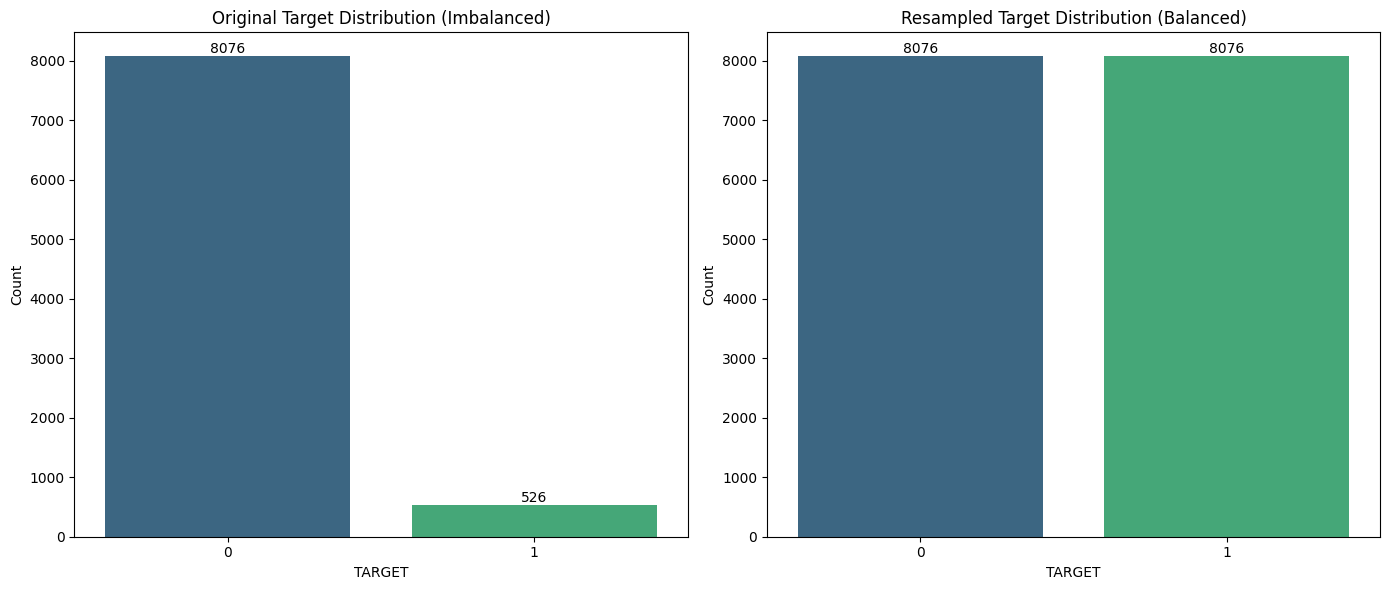

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot original (imbalanced) data
sns.countplot(x=y, ax=axes[0], palette='viridis', hue=y, legend=False)
axes[0].set_title('Original Target Distribution (Imbalanced)')
axes[0].set_xlabel('TARGET')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

# Plot resampled (balanced) data
sns.countplot(x=y_resampled, ax=axes[1], palette='viridis', hue=y_resampled, legend=False)
axes[1].set_title('Resampled Target Distribution (Balanced)')
axes[1].set_xlabel('TARGET')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()